In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import mnist_reader
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, v_measure_score
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import fcluster, dendrogram, linkage

In [3]:
X_train, y_train = mnist_reader.load_mnist('data/fashion', kind='train')
X_test, y_test = mnist_reader.load_mnist('data/fashion', kind='t10k')

print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)

X_train_norm = X_train / 255.0
print("\n=== Estadísticas (datos sin normalizar) ===")
print(f"Valor mínimo:      {X_train.min()}")
print(f"Valor máximo:      {X_train.max()}")
print(f"Media:             {X_train.mean():.2f}")
print(f"Desviación típica: {X_train.std():.2f}")

Forma de X_train: (60000, 784)
Forma de y_train: (60000,)

=== Estadísticas (datos sin normalizar) ===
Valor mínimo:      0
Valor máximo:      255
Media:             72.94
Desviación típica: 90.02


In [4]:
# Distribución de clases
unique, counts = np.unique(y_train, return_counts=True)
print("\nDistribución de clases:")
for i, c in zip(unique, counts):
    print(f"  Clase {i}: {c} muestras")


Distribución de clases:
  Clase 0: 6000 muestras
  Clase 1: 6000 muestras
  Clase 2: 6000 muestras
  Clase 3: 6000 muestras
  Clase 4: 6000 muestras
  Clase 5: 6000 muestras
  Clase 6: 6000 muestras
  Clase 7: 6000 muestras
  Clase 8: 6000 muestras
  Clase 9: 6000 muestras


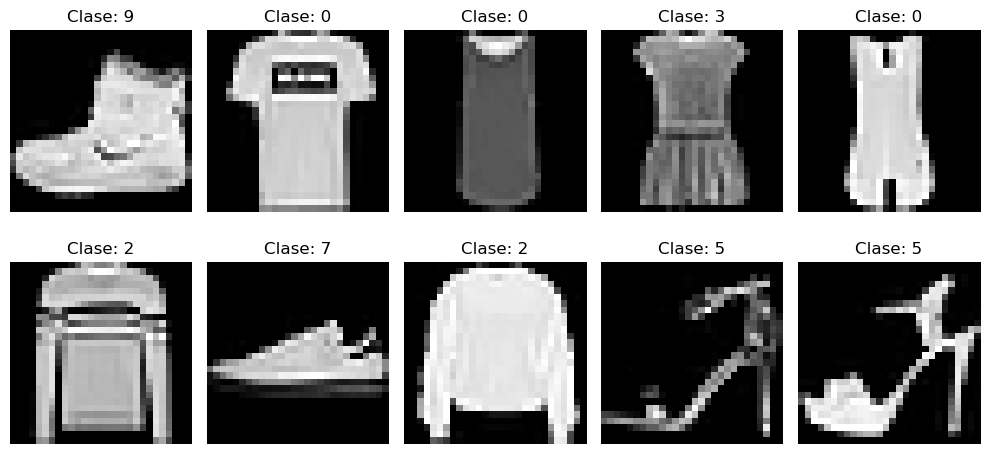

In [5]:

#Imágenes
fig , axes = plt.subplots(2, 5, figsize = (10,5))

for i,ax in  enumerate(axes.flat):
    ax.imshow(X_train_norm[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Clase: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

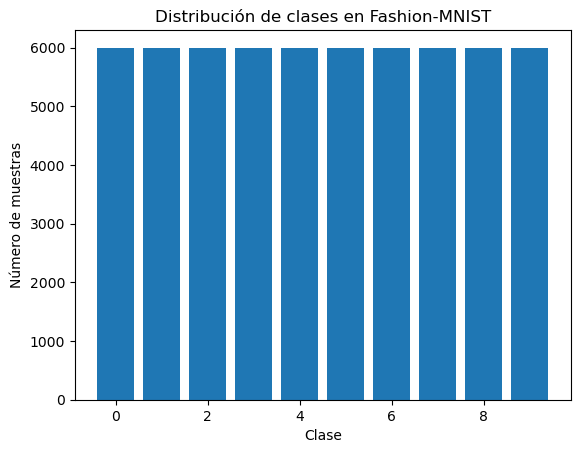

In [6]:
unique, counts = np.unique(y_train, return_counts=True)

plt.bar(unique, counts)
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.title("Distribución de clases en Fashion-MNIST")
plt.show()


In [7]:
#Normalización

X_train_norm = X_train / 255.0
#Resumen estadístico despues de normalizar
print(f"Valor mínimo:      {X_train_norm.min():.2f}")
print(f"Valor máximo:      {X_train_norm.max():.2f}")
print(f"Media:             {X_train_norm.mean():.3f}")
print(f"Desviación típica: {X_train_norm.std():.3f}")

Valor mínimo:      0.00
Valor máximo:      1.00
Media:             0.286
Desviación típica: 0.353


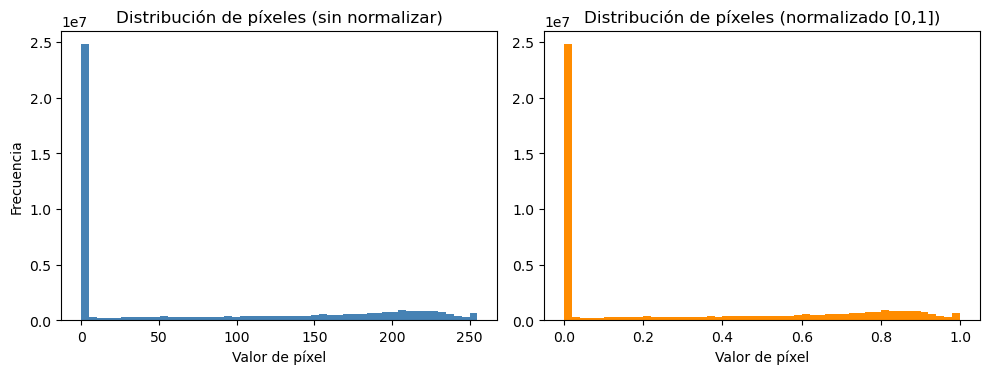

In [8]:
# Histograma de valores de píxel antes y después
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train.flatten(), bins=50, color='steelblue')
axes[0].set_title("Distribución de píxeles (sin normalizar)")
axes[0].set_xlabel("Valor de píxel")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(X_train_norm.flatten(), bins=50, color='darkorange')
axes[1].set_title("Distribución de píxeles (normalizado [0,1])")
axes[1].set_xlabel("Valor de píxel")

plt.tight_layout()
plt.show()

In [9]:
#Identificación de valores atípicos

# Calculamos la norma L2 de cada imagen (suma total de intensidad).
# Imágenes con norma muy alta o muy baja pueden ser atípicas.
normas = np.linalg.norm(X_train_norm, axis=1)

media_norma = normas.mean()
std_norma   = normas.std()

In [10]:
# Consideramos atípica toda imagen que se aleje más de 3 desviaciones típicas
umbral_sup = media_norma + 3 * std_norma
umbral_inf = media_norma - 3 * std_norma

outliers_idx = np.where((normas > umbral_sup) | (normas < umbral_inf))[0]

print(f"\n=== Identificación de valores atípicos ===")
print(f"Media de normas:       {media_norma:.3f}")
print(f"Desviación típica:     {std_norma:.3f}")
print(f"Umbral superior (+3σ): {umbral_sup:.3f}")
print(f"Umbral inferior (-3σ): {umbral_inf:.3f}")
print(f"Imágenes atípicas encontradas: {len(outliers_idx)} "
      f"({len(outliers_idx)/len(X_train_norm)*100:.2f}% del total)")


=== Identificación de valores atípicos ===
Media de normas:       12.152
Desviación típica:     3.765
Umbral superior (+3σ): 23.448
Umbral inferior (-3σ): 0.856
Imágenes atípicas encontradas: 0 (0.00% del total)


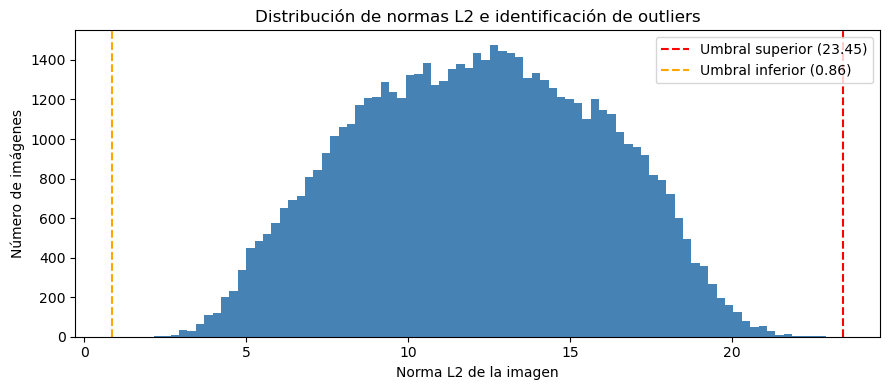

In [11]:
# Distribución de normas con umbrales
plt.figure(figsize=(9, 4))
plt.hist(normas, bins=80, color='steelblue', edgecolor='none')
plt.axvline(umbral_sup, color='red',    linestyle='--', label=f'Umbral superior ({umbral_sup:.2f})')
plt.axvline(umbral_inf, color='orange', linestyle='--', label=f'Umbral inferior ({umbral_inf:.2f})')
plt.xlabel("Norma L2 de la imagen")
plt.ylabel("Número de imágenes")
plt.title("Distribución de normas L2 e identificación de outliers")
plt.legend()
plt.tight_layout()
plt.show()

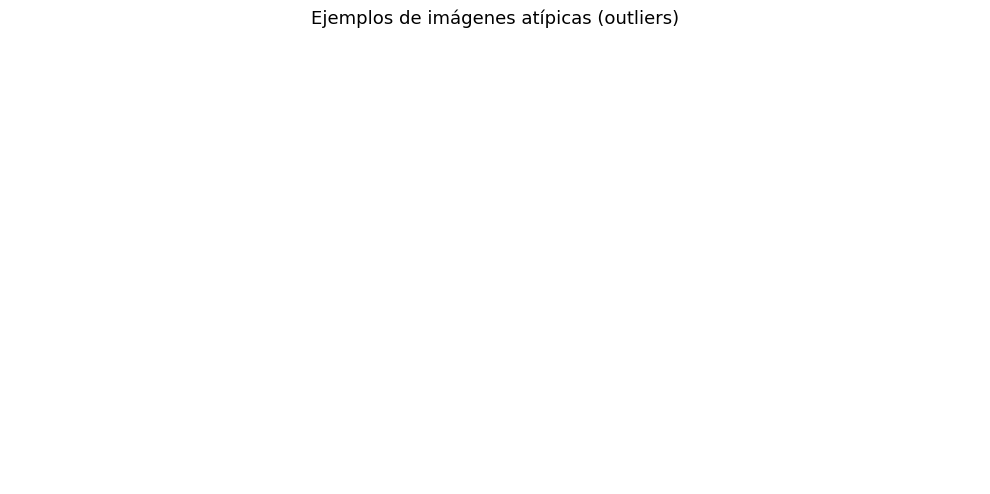

In [12]:

# Mostramos algunos ejemplos de imágenes atípicas
n_mostrar = min(10, len(outliers_idx))
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    if i < n_mostrar:
        ax.imshow(X_train_norm[outliers_idx[i]].reshape(28, 28), cmap='gray')
        ax.set_title(f"Norma: {normas[outliers_idx[i]]:.2f}\nClase: {y_train[outliers_idx[i]]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Ejemplos de imágenes atípicas (outliers)", fontsize=13)
plt.tight_layout()
plt.show()

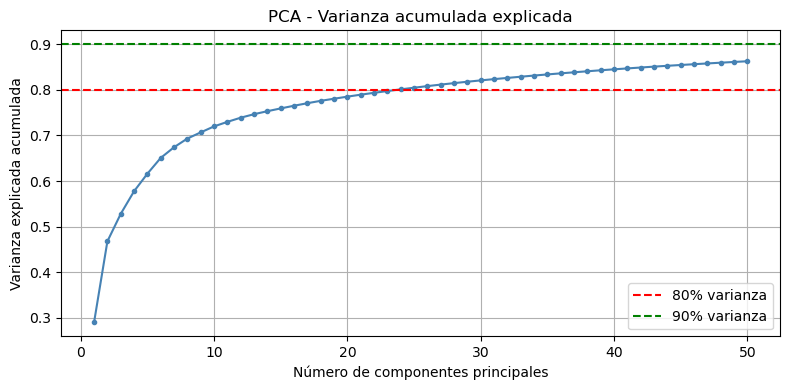

In [13]:
#Reducción de dimensionalidad
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_norm)

varianza_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 51), varianza_acum, marker='o', markersize=3, color='steelblue')
plt.axhline(y=0.80, color='red',   linestyle='--', label='80% varianza')
plt.axhline(y=0.90, color='green', linestyle='--', label='90% varianza')
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza acumulada explicada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
n_80 = np.argmax(varianza_acum >= 0.80) + 1
n_90 = np.argmax(varianza_acum >= 0.90) + 1
print(f"\nComponentes necesarios para explicar el 80% de varianza: {n_80}")
print(f"Componentes necesarios para explicar el 90% de varianza: {n_90}")
print(f"Varianza explicada total con 50 componentes: {varianza_acum[-1]:.3f}")


Componentes necesarios para explicar el 80% de varianza: 24
Componentes necesarios para explicar el 90% de varianza: 1
Varianza explicada total con 50 componentes: 0.863


# Modelos 

In [15]:
k_list = range(2,16)
distortions = []
silhouette = []
v_measure = []

for k in k_list:
    model = KMeans(n_clusters=k, init= "random" )
    model.fit(X_train_pca)
    distortions.append(model.inertia_)
    label = model.predict(X_train_pca)
    silhouette.append(silhouette_score(X_train_pca, label))
    v_measure.append(v_measure_score(y_train, label))

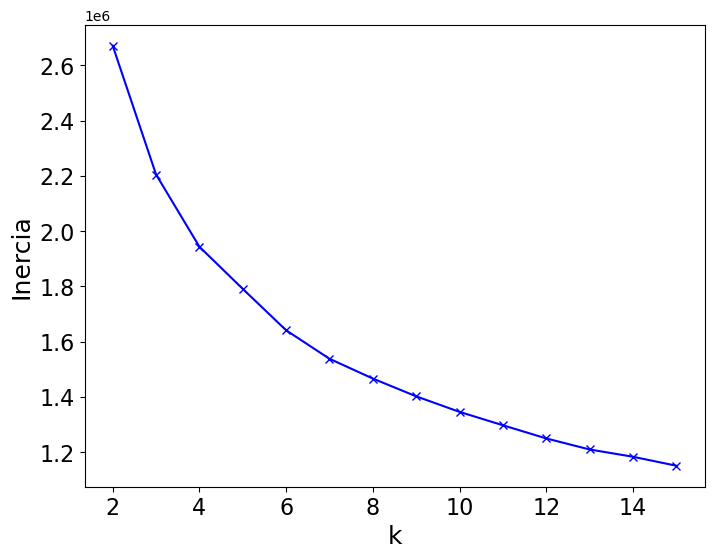

In [16]:
plt.figure(figsize = (8,6))
plt.plot(k_list, distortions, "bx-")
plt.xlabel("k", fontsize = 18)
plt.ylabel("Inercia", fontsize = 18)
plt.setp(plt.gca().get_xticklabels(), fontsize=16)
plt.setp(plt.gca().get_yticklabels(), fontsize=16)
plt.show()

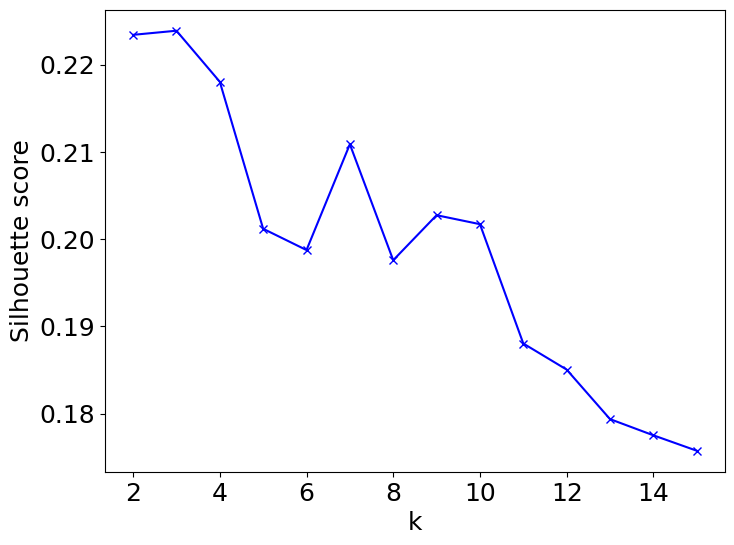

In [17]:
plt.figure(figsize=(8,6))
plt.plot(k_list, silhouette, "bx-")
plt.xlabel("k", fontsize=18)
plt.ylabel("Silhouette score", fontsize =18)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show()

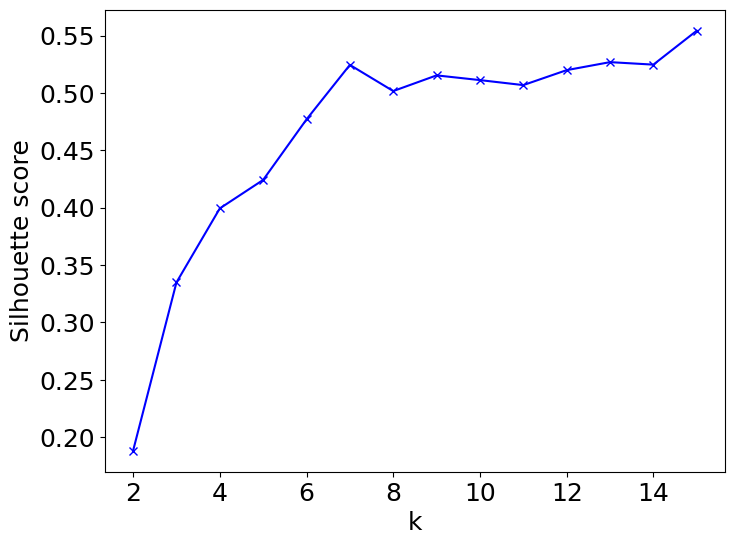

In [18]:
plt.figure(figsize=(8,6))
plt.plot(k_list, v_measure, "bx-")
plt.xlabel("k", fontsize=18)
plt.ylabel("Silhouette score", fontsize =18)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show()

In [ ]:
k_list = range(2, 16)
 
distortions_random = []
silhouette_random = []
v_measure_random = []
 
distortions_pp = []
silhouette_pp = []
v_measure_pp = []
 
 
for k in k_list:
    # K-Means random
    model_random = KMeans(n_clusters=k, init='random')
    model_random.fit(X_train_pca)
    label_random = model_random.predict(X_train_pca)
    distortions_random.append(model_random.inertia_)
    silhouette_random.append(silhouette_score(X_train_pca, label))
    v_measure_random.append(v_measure_score(y_train, label))
 
    # K-Means++
    model_pp = KMeans(n_clusters=k, init='k-means++')
    model_pp.fit(X_train_pca)
    label_pp = model_pp.predict(X_train_pca)
    distortions_pp.append(model_pp.inertia_)
    silhouette_pp.append(silhouette_score(X_train_pca, label))
    v_measure_pp.append(v_measure_score(y_train, label))

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(k_list, distortions_random, "bx-", label="random")
plt.plot(k_list, distortions_pp,     "rx-", label="k-means++")
plt.xlabel("k", fontsize=18)
plt.ylabel("Inercia", fontsize=18)
plt.legend(fontsize=13)
plt.setp(plt.gca().get_xticklabels(), fontsize=16)
plt.setp(plt.gca().get_yticklabels(), fontsize=16)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(k_list, silhouette_random, "bx-", label="random")
plt.plot(k_list, silhouette_pp,     "rx-", label="k-means++")
plt.xlabel("k", fontsize=18)
plt.ylabel("Silhouette score", fontsize=18)
plt.legend(fontsize=13)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(k_list, v_measure_random, "bx-", label="random")
plt.plot(k_list, v_measure_pp,     "rx-", label="k-means++")
plt.xlabel("k", fontsize=18)
plt.ylabel("V-measure score", fontsize=18)
plt.legend(fontsize=13)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show(

## DBSCAN


grupos detectados:  0
datos clasificados como ruido:  60000


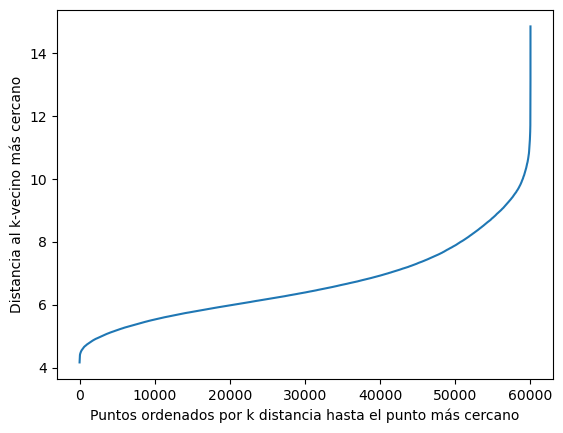

In [19]:
n, dim = X_train_norm.shape
MinPts = 2*dim

neighbors = NearestNeighbors(n_neighbors=MinPts)
neighbors.fit(X_train_norm)
distances, indices = neighbors.kneighbors(X_train_norm)
distances = np.sort(distances[:, MinPts-1])

plt.plot(distances)
plt.xlabel("Puntos ordenados por k distancia hasta el punto más cercano")
plt.ylabel("Distancia al k-vecino más cercano")

clustering = DBSCAN(eps = 0.6, min_samples= MinPts).fit(X_train_norm)
n_c = np.max(clustering.labels_)+1
print("grupos detectados: ",n_c)
print("datos clasificados como ruido: ", sum(clustering.labels_ == -1))

## Jerarquico

In [1]:
np.random.seed(42)
n_muestra = 200
idx_muestra = np.random.choice(len(X_train_pca), n_muestra, replace=False)
X_jerarquico = X_train_pca[idx_muestra]
y_jerarquico = y_train[idx_muestra]
dist = pdist(X_train_norm)
linkage_matrix = linkage(dist, "complete")
 
plt.figure(X_train_norm)
dendrogram(linkage_matrix)
 
k = 10
herar_tags = fcluster(linkage_matrix, k, criterion='maxclust')
 
pca_2d = PCA(n_components=2, random_state=42)
X_viz = pca_2d.fit_transform(X_train_norm)
 
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_viz[:, 0], X_viz[:, 1],
                      c=herar_tags, cmap='viridis', s=15, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Grupos")
plt.title("Agrupamiento obtenido")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined